# Numerical Modeling of the 2-D Burgers' Equation (FDM)

**Methods:** Finite differences (forward-time, backward-space advection, centered diffusion), NumPy, Matplotlib

### Overview
This notebook models 2-D Burgers' with periodic and Neumann BCs, plus the nonlinear T-dependent case.

----

This notebook develops a finite difference method (FDM) model for the two-dimensional Burgers equation shown below. The model uses forward-in-time and backward-in-space differencing for the first-derivative terms, while centered differencing is applied to the second-derivative terms. Appropriate diffusion and discretization parameters, including $\Delta t$, $\Delta x$, and $\Delta y$, are selected to maintain numerical stability. To simplify the model, $\Delta x=\Delta y$ is assumed unless otherwise stated, and all parameters are treated as constant.

\begin{align}
\frac{\partial{T}}{\partial{t}}+a\left(\frac{\partial T}{\partial x}+\frac{\partial T}{\partial y}\right)=\nu\left(\frac{\partial^2T}{\partial x^2}+\frac{\partial^2T}{\partial y^2}\right)
\end{align}

The behavior of the system is investigated under different boundary conditions:

1. Periodic or cyclic boundary conditions.

2. Neumann boundary conditions in one direction and cyclic boundary conditions in the other direction.

Here I also extends the model by replacing the constant flow parameter with the dependent variable itself:

\begin{align}
\frac{\partial{T}}{\partial{t}}+T\left(\frac{\partial T}{\partial x}+\frac{\partial T}{\partial y}\right)=\nu\left(\frac{\partial^2T}{\partial x^2}+\frac{\partial^2T}{\partial y^2}\right)
\end{align}

The behavior of this nonlinear system is compared with the first model under periodic boundary conditions. This comparison is used to examine how the second term affects the flow and to interpret its physical meaning within the system.


FDM solutions:

\begin{equation}
  u_{i,j}^{n+1} = u_{i,j}^{n} + \frac{\nu \Delta t}{\Delta x^2} \left( u_{i+1,j}^{n} + u_{i-1,j}^{n} + u_{i,j+1}^{n} + u_{i,j-1}^{n} - 4u_{i,j}^{n} \right) - \frac{a \Delta t}{\Delta x} \left( 2u_{i,j}^{n} - u_{i-1,j}^{n} - u_{i,j-1}^{n} \right)
\end{equation}

---

#### Describing the parameters for `alpha`, `dx`, `d`, `dt`

Where `alpha` is $\frac{a \Delta t}{\Delta x}$,
`d` is $\frac{\nu \Delta t}{\Delta x^2}$

In [1]:
alpha = 0.05
d = 0.1

dx = 0.1
v = 0.25
dt = d*dx*dx/v
a = alpha*dx/dt

time_for_video = 15 #Change end time for all video here
vid_step = 30 #Change step per frame for all video here

#### Import necessary library, Create functions to easily plot the graph, and Create blank graph space to make video process faster

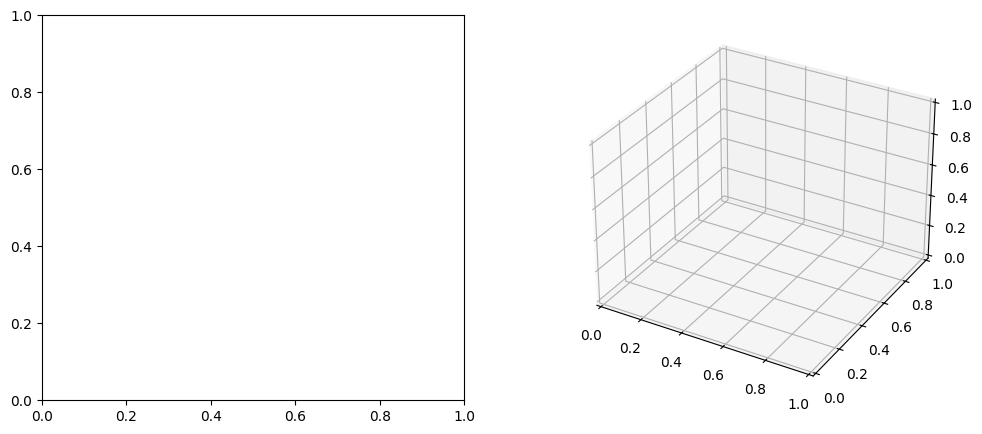

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import Video, display
from mpl_toolkits.mplot3d import Axes3D
from PIL import Image
from IPython.display import Image as IPyImage

def visualize_2d(ax, data, vmin, vmax, time, frame_step):
  ax.clear()
  pixel_plot = ax.imshow(data, cmap='nipy_spectral', interpolation='nearest', vmin=vmin, vmax=vmax)
  fig = ax.get_figure()
  fig.colorbar(pixel_plot, ax=ax, shrink=0.5, aspect=5)
  ax.set_title(f'2D Plot at Time: {time*frame_step:.5f}')
  ax.set_xlabel('X-axis')
  ax.set_ylabel('Y-axis')

def visualize_3d(ax, data, vmin, vmax, time, frame_step):
  ax.clear()
  x, y = np.meshgrid(np.arange(data.shape[1]), np.arange(data.shape[0]))
  surf = ax.plot_surface(x, y, data, cmap='nipy_spectral', vmin=vmin, vmax=vmax)
  fig = ax.get_figure()
  #fig.colorbar(surf, ax=ax, shrink=0.5, aspect=5)
  ax.set_title(f'3D Surface at Time: {time*frame_step:.5f}')
  ax.set_xlabel('X-axis')
  ax.set_ylabel('Y-axis')
  ax.set_zlim(vmin, vmax)
  ax.invert_yaxis()

def visualize(data, vmin, vmax, time, frame_step):
  fig = plt.figure(figsize=(12, 5))
  ax1 = fig.add_subplot(1, 2, 1)
  ax2 = fig.add_subplot(1, 2, 2, projection='3d')
  visualize_2d(ax1, data, vmin, vmax, time, frame_step)
  visualize_3d(ax2, data, vmin, vmax, time, frame_step)
  plt.tight_layout()
  plt.show()
  plt.close(fig)

import os
os.makedirs("frames", exist_ok=True)

#Create blank graph area so it run faster later on
fig_anim = plt.figure(figsize=(12, 5))
ax1_anim = fig_anim.add_subplot(1, 2, 1)
ax2_anim = fig_anim.add_subplot(1, 2, 2, projection='3d')


def frame_animation(data, vmin, vmax, step, frame_step):
  fig = plt.figure(figsize=(12, 5))
  ax1 = fig.add_subplot(1, 2, 1)
  ax2 = fig.add_subplot(1, 2, 2, projection='3d')
  visualize_2d(ax1, data, vmin, vmax, time=step*dt, frame_step = frame_step)
  visualize_3d(ax2, data, vmin, vmax, time=step*dt, frame_step = frame_step)
  plt.tight_layout()
  plt.savefig(f"frames/frame_{step:05d}.png")
  plt.close(fig)

import glob
def clear_frames():
  for f in glob.glob("frames/*"):
    os.remove(f)

from tqdm import tqdm

### Periodic/Cyclic boundary conditions

Setting up the domain at `Time step = 0`.

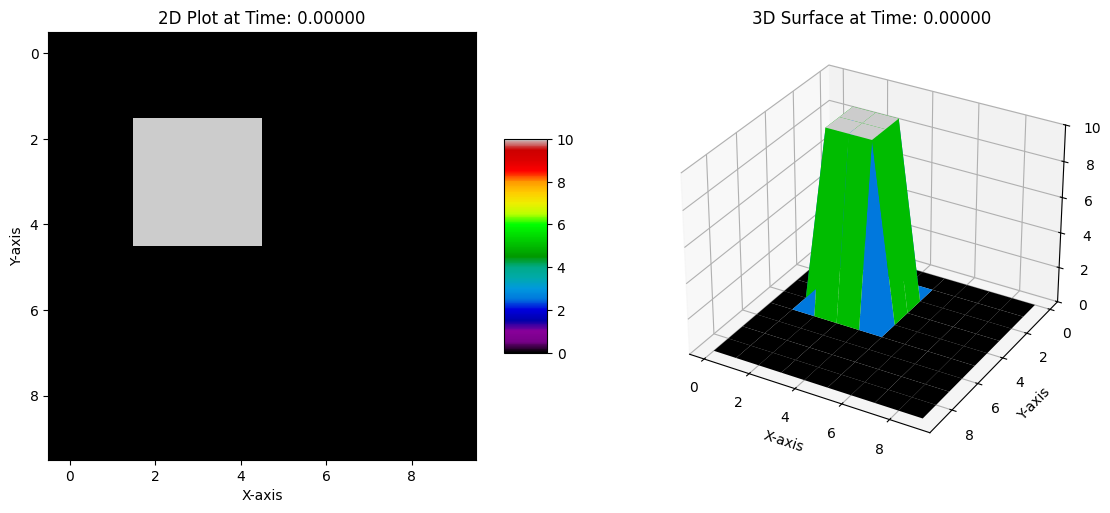

In [3]:
n = 0
grid_x = 10
grid_y = 10
T = np.zeros((grid_y, grid_x))
T[2:5, 2:5] = 10.0
visualize(T,vmin = 0, vmax = 10, time = n, frame_step = 1)

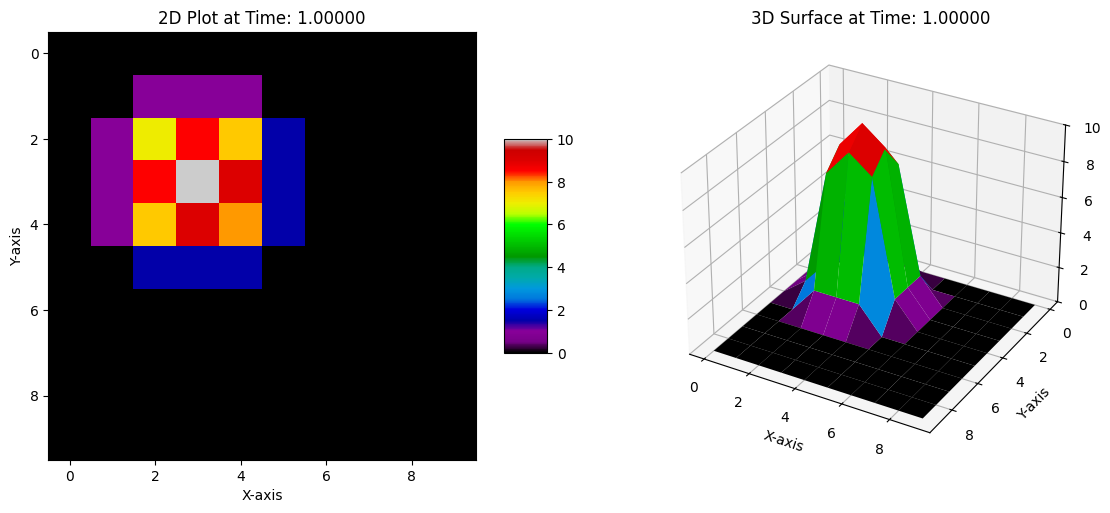

In [4]:
n = n + 1 #To show step order by the number of time we run this cell
T = T + d*(np.roll(T, -1, 0)+np.roll(T, 1, 0)+np.roll(T, -1, 1)+np.roll(T, 1, 1)-4.0*T) - alpha*(2.0*T-np.roll(T, 1, 0)-np.roll(T, 1, 1))
visualize(T,vmin = 0, vmax = 10, time = n, frame_step = 1)

Using `for-loop` function in bigger domain to see the result at determined time interval.

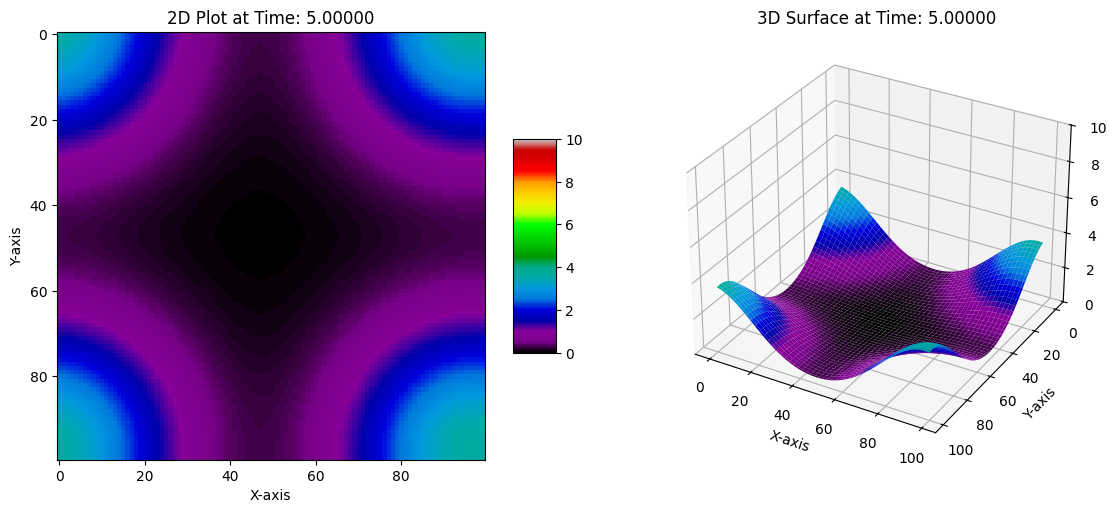

In [5]:
grid_x = 100
grid_y = 100
T = np.zeros((grid_y, grid_x))
T[20:50, 20:50] = 10

end_t = 5
n_total = end_t/dt

for n in range(0, int(n_total)+1) :
  T = T + d*(np.roll(T, -1, 0)+np.roll(T, 1, 0)+np.roll(T, -1, 1)+np.roll(T, 1, 1)-4.0*T) - alpha*(2.0*T-np.roll(T, 1, 0)-np.roll(T, 1, 1))
visualize(T, vmin = 0, vmax = 10, time = (n+1)*dt, frame_step = 1)

#### For Video (Periodic/Cyclic boundary conditions)

In [6]:
grid_x = 100
grid_y = 100
T = np.zeros((grid_y, grid_x))
T[20:50, 20:50] = 10

end_t = time_for_video #Change the time here
n_total = end_t/dt
step_per_frame = vid_step #Change step per frame here

clear_frames()
pbar = tqdm(total=int(n_total//step_per_frame), desc="Video Progress")

for n in range(0, int(n_total)+1) :
  if n%step_per_frame == 0:
    frame_animation(T, vmin = 0, vmax = 10, step = n//step_per_frame, frame_step = step_per_frame)
    pbar.update(1)
  T = T + d*(np.roll(T, -1, 0)+np.roll(T, 1, 0)+np.roll(T, -1, 1)+np.roll(T, 1, 1)-4.0*T) - alpha*(2.0*T-np.roll(T, 1, 0)-np.roll(T, 1, 1))
pbar.close()

files = sorted(glob.glob("frames/frame_*.png"))
imgs = [Image.open(f) for f in files]
if imgs:
    imgs[0].save("Periodic_Cyclic.gif", save_all=True,
                 append_images=imgs[1:], duration=50, loop=0)

# IPyImage(filename="Periodic_Cyclic.gif") # render inline in the notebook

# !ffmpeg -framerate 20 -i frames/frame_%05d.png -c:v libx264 -pix_fmt yuv420p -y Periodic_Cyclic.mp4
# display(Video("Periodic_Cyclic.mp4")) #If video is not available try find the video in file name "Periodic_Cyclic.mp4" since it had already been downloaded

Video Progress: 125it [01:02,  2.00it/s]                         


![Burgers' equation, periodic boundary conditions](Periodic_Cyclic.gif)

### Neumann boundary condition (no flux) through Y-walls

Setting up the domain at `Time step = 0`.

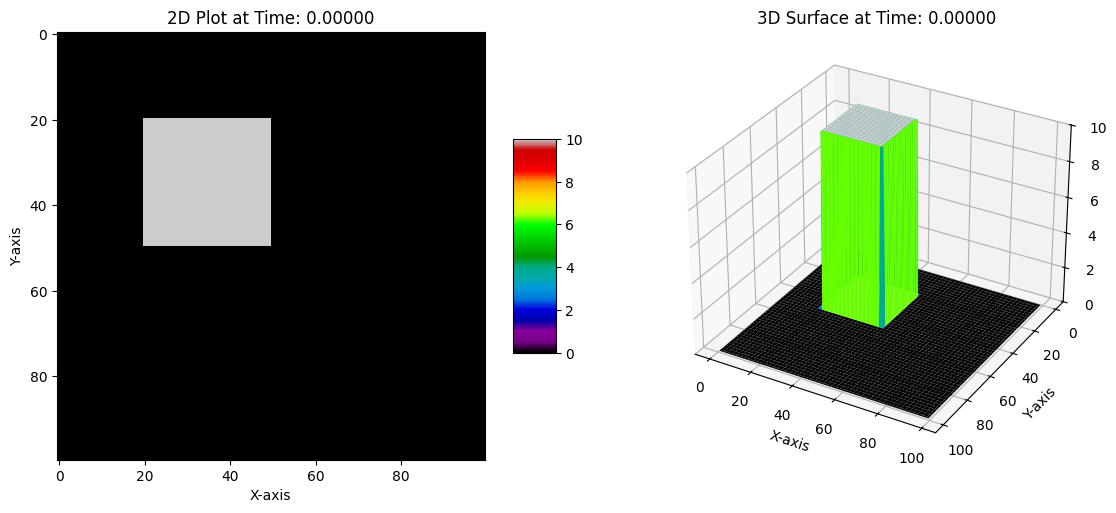

In [7]:
grid_x = 100
grid_y = 100
T = np.zeros((grid_y, grid_x))
T[20:50, 20:50] = 10
T[:, 0] = T[:, 0] + d*(np.roll(T[:, 0], -1)+np.roll(T[:, 0], 1)+T[:, 1]+T[:, 1]-4*T[:,0]) - alpha*(2.0*T[:, 0]-np.roll(T[:, 0], 1, 0)-T[:, 1]) #Does not effect anyway since the source is still inside the domain (Not reaching the edge yet)
T[:, -1] = T[:, -1] + d*(np.roll(T[:, -1], -1)+np.roll(T[:, -1], 1)+T[:, -2]+T[:, -2]-4*T[:, -1]) - alpha*(2.0*T[:, -1]-np.roll(T[:, -1], 1, 0)-T[:, -2]) #Does not effect anyway since the source is still inside the domain (Not reaching the edge yet)

visualize(T, vmin = 0, vmax = 10, time = 0, frame_step = 1)

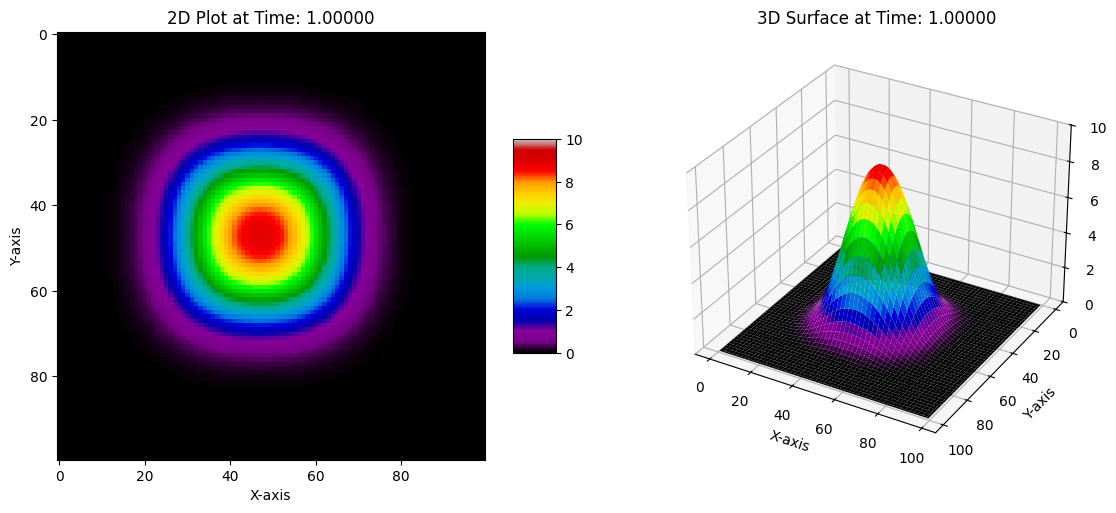

In [8]:
end_t = 1
n_total = end_t/dt

for n in range(0, int(n_total)+1) :
  T[:, 0] = T[:, 0] + d*(np.roll(T[:, 0], -1)+np.roll(T[:, 0], 1)+T[:, 1]+T[:, 1]-4*T[:,0]) - alpha*(2.0*T[:, 0]-np.roll(T[:, 0], 1, 0)-T[:, 1]) #T[:, 1] instead of T[:, -2] because bounce back
  T[:, -1] = T[:, -1] + d*(np.roll(T[:, -1], -1)+np.roll(T[:, -1], 1)+T[:, -2]+T[:, -2]-4*T[:, -1]) - alpha*(2.0*T[:, -1]-np.roll(T[:, -1], 1, 0)-T[:, -2]) #T[:, -2] instead of T[:, 1] because bounce back
  T[:, 1:-1] = T[:, 1:-1] + d*(np.roll(T[:, 1:-1], -1, 0)+np.roll(T[:, 1:-1], 1, 0)+T[:, 2:]+T[:, 0:-2]-4*T[:,1:-1]) - alpha*(2.0*T[:, 1:-1]-np.roll(T[:, 1:-1], 1, 0)-T[:, 0:-2]) #Middle part
visualize(T, vmin = 0, vmax = 10, time = (n+1)*dt, frame_step = 1)

In this part we still use `np.roll` for movement of row matrix since we want to keep cyclic conditions for X-direction.

#### For Video (Neumann boundary condition (no flux) through Y-walls)

In [9]:
grid_x = 100
grid_y = 100
T = np.zeros((grid_y, grid_x))
T[20:50, 20:50] = 10

end_t = time_for_video #Change the time here
n_total = end_t/dt
step_per_frame = vid_step #Change step per frame here

clear_frames()
pbar = tqdm(total=int(n_total//step_per_frame), desc="Video Progress")

for n in range(0, int(n_total)+1) :
  if n%step_per_frame == 0:
    frame_animation(T, vmin = 0, vmax = 10, step = n//step_per_frame, frame_step = step_per_frame)
    pbar.update(1)
  T[:, 0] = T[:, 0] + d*(np.roll(T[:, 0], -1)+np.roll(T[:, 0], 1)+T[:, 1]+T[:, 1]-4*T[:,0]) - alpha*(2.0*T[:, 0]-np.roll(T[:, 0], 1, 0)-T[:, 1]) #T[:, 1] instead of T[:, -2] because bounce back
  T[:, -1] = T[:, -1] + d*(np.roll(T[:, -1], -1)+np.roll(T[:, -1], 1)+T[:, -2]+T[:, -2]-4*T[:, -1]) - alpha*(2.0*T[:, -1]-np.roll(T[:, -1], 1, 0)-T[:, -2]) #T[:, -2] instead of T[:, 1] because bounce back
  T[:, 1:-1] = T[:, 1:-1] + d*(np.roll(T[:, 1:-1], -1, 0)+np.roll(T[:, 1:-1], 1, 0)+T[:, 2:]+T[:, 0:-2]-4*T[:,1:-1]) - alpha*(2.0*T[:, 1:-1]-np.roll(T[:, 1:-1], 1, 0)-T[:, 0:-2]) #Middle part
pbar.close()

files = sorted(glob.glob("frames/frame_*.png"))
imgs = [Image.open(f) for f in files]
if imgs:
    imgs[0].save("Neumann_Y.gif", save_all=True,
                 append_images=imgs[1:], duration=50, loop=0)

# IPyImage(filename="Neumann_Y.gif") # render inline in the notebook

# !ffmpeg -framerate 20 -i frames/frame_%05d.png -c:v libx264 -pix_fmt yuv420p -y Neumann_Y.mp4
# display(Video("Neumann_Y.mp4")) #If video is not available try find the video in file name "Periodic_Cyclic.mp4" since it had already been downloaded

Video Progress: 125it [01:03,  1.98it/s]                         


![Burgers' equation, Neumann (no-flux) through Y-walls](Neumann_Y.gif)

### If `alpha` is depends on `T` (change a to T)

Therefore, the system becomes Non-linear which can use the same code for Periodic/Cyclic boundary conditions but change from `a` to `T`

Setting up the domain at `Time step = 0`.

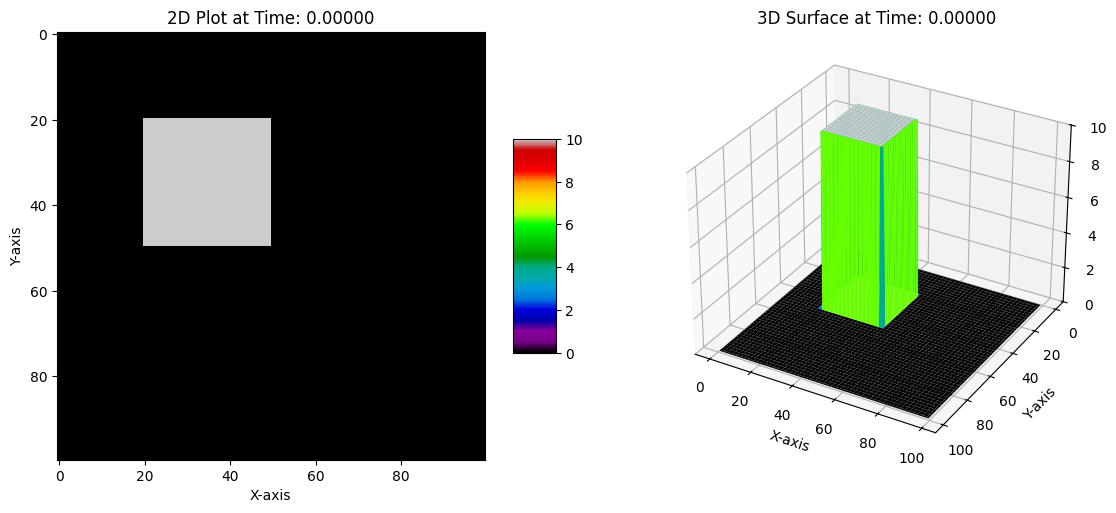

In [10]:
n = 0
grid_x = 100
grid_y = 100
T = np.zeros((grid_y, grid_x))
T[20:50, 20:50] = 10.0
visualize(T,vmin = 0, vmax = 10, time = n, frame_step = 1)

Using `for-loop` function in bigger domain to see the result at determined time interval.

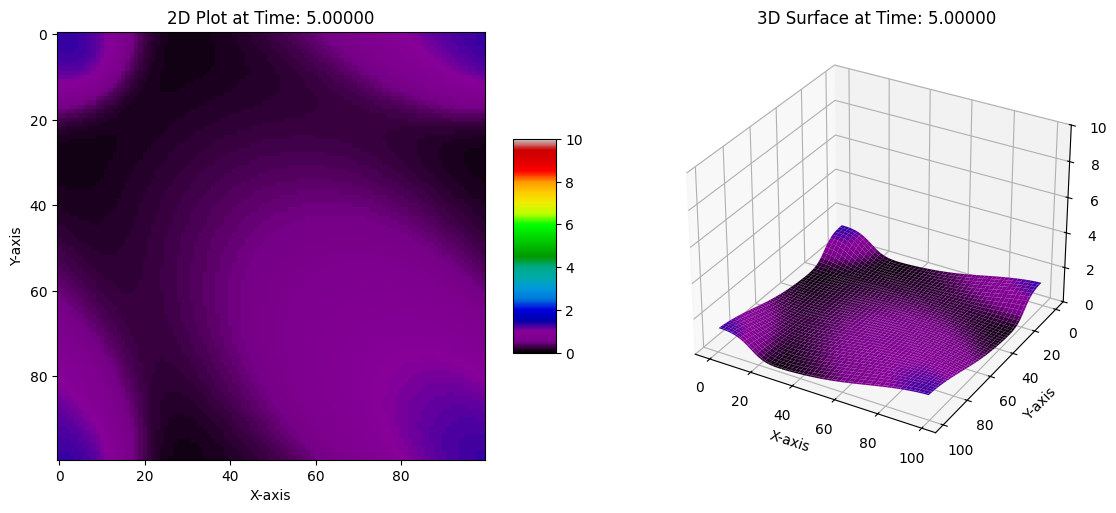

In [11]:
grid_x = 100
grid_y = 100
T = np.zeros((grid_y, grid_x))
T[20:50, 20:50] = 10

end_t = 5
n_total = end_t/dt

for n in range(0, int(n_total)+1) :
  T = T + d*(np.roll(T, -1, 0)+np.roll(T, 1, 0)+np.roll(T, -1, 1)+np.roll(T, 1, 1)-4.0*T) - T*(alpha/a)*(2.0*T-np.roll(T, 1, 0)-np.roll(T, 1, 1))
visualize(T, vmin = 0, vmax = 10, time = (n+1)*dt, frame_step = 1)

#### For Video (Periodic/Cyclic boundary conditions)

In [12]:
grid_x = 100
grid_y = 100
T = np.zeros((grid_y, grid_x))
T[20:50, 20:50] = 10

end_t = time_for_video #Change the time here
n_total = end_t/dt
step_per_frame = 20 #Change step per frame here

clear_frames()
pbar = tqdm(total=int(n_total//step_per_frame), desc="Video Progress")

for n in range(0, int(n_total)+1) :
  if n%step_per_frame == 0:
    frame_animation(T, vmin = 0, vmax = 10, step = n//step_per_frame, frame_step = step_per_frame)
    pbar.update(1)
  T = T + d*(np.roll(T, -1, 0)+np.roll(T, 1, 0)+np.roll(T, -1, 1)+np.roll(T, 1, 1)-4.0*T) - T*(alpha/a)*(2.0*T-np.roll(T, 1, 0)-np.roll(T, 1, 1))
pbar.close()

files = sorted(glob.glob("frames/frame_*.png"))
imgs = [Image.open(f) for f in files]
if imgs:
    imgs[0].save("T_Dependent_Periodic_Cyclic.gif", save_all=True,
                 append_images=imgs[1:], duration=50, loop=0)

# IPyImage(filename="T_Dependent_Periodic_Cyclic.gif") # render inline in the notebook

#!ffmpeg -framerate 20 -i frames/frame_%05d.png -c:v libx264 -pix_fmt yuv420p -y T_Dependent_Periodic_Cyclic.mp4
#display(Video("T_Dependent_Periodic_Cyclic.mp4")) #If video is not available try find the video in file name "Periodic_Cyclic.mp4" since it had already been downloaded

Video Progress: 188it [01:36,  1.95it/s]                         


![Nonlinear case: advection coefficient depends on T](T_Dependent_Periodic_Cyclic.gif)

Due to we change 2nd term (1st derivative of space) from constant `a` to `T` (temperature-dependent) which is decreasing over time. At the beginning, when the temperature T is high, the damping effect is strong So, the system absorbs energy quickly. However, as `T` decreases over time due to diffusion and absorption, the damping effect also weakens.

As a result, the system loses energy quickly at first, but more slowly later, because there is less remaining heat to be absorbed. This models a situation where the ability to absorb energy depends on how much energy is in the system.

### Compare the behavior  and discuss the results

#### Now we compared Relation Between `alpha` and `d` in Neumann boundary condition (no flux) through Y-walls cases

We compare 4 cases below :
- `alpha` = `0`
- `alpha` = `d`
- `alpha` > `d`
- `alpha` << `d`

The behavior of the field depends on the balance between `alpha` and the diffusion coefficient `d`. A larger `alpha` strengthens the damping term, causing the field to be absorbed faster. For example, when `alpha = 0.25`, the damping dominates the system, and the field eventually decays to zero regardless of the value of `d`.

Reducing `alpha` weakens this effect, which allow the influence of diffusion to become more visible. The comparison below varies `alpha` while keeping `d` fixed to demonstrate this balance.

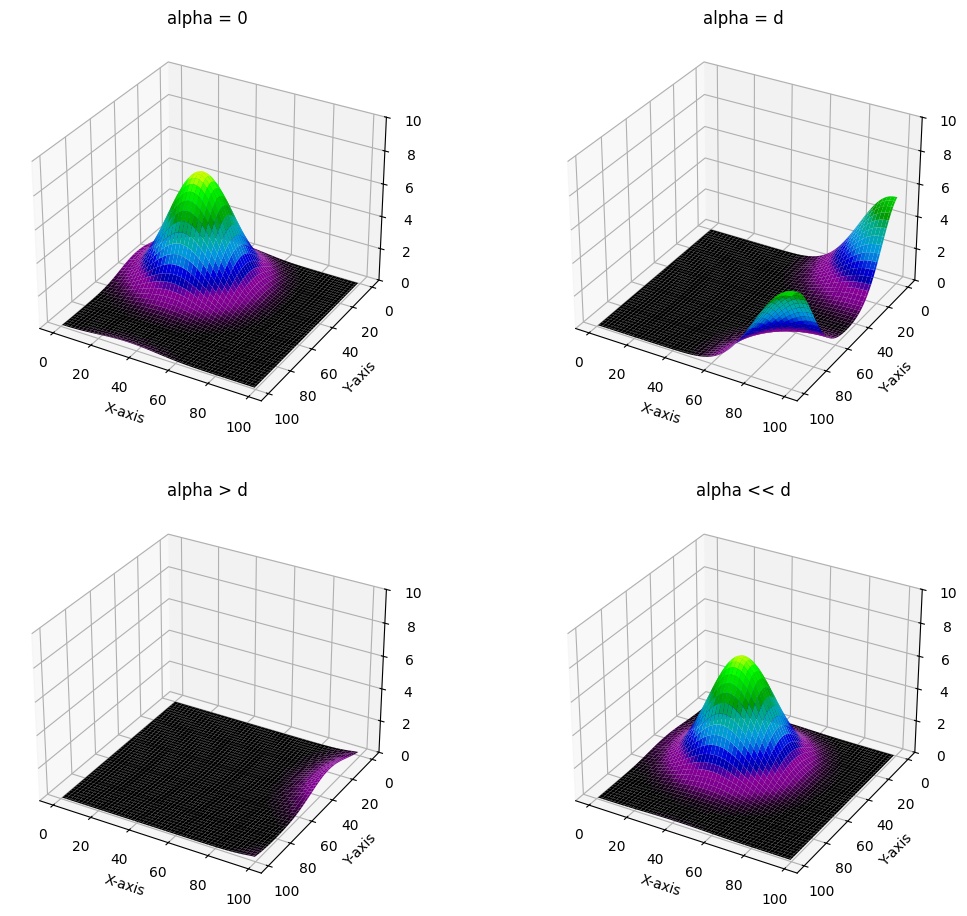

In [13]:
grid_x = 100
grid_y = 100
T1 = np.zeros((grid_y, grid_x))
T2 = np.zeros((grid_y, grid_x))
T3 = np.zeros((grid_y, grid_x))
T4 = np.zeros((grid_y, grid_x))
for T in [T1, T2, T3, T4]:
  T[20:50, 20:50] = 10

d = 0.1
alpha1 = 0
alpha2 = 0.1
alpha3 = 0.15
alpha4 = 0.01

end_t = 2.5
n_total = end_t/dt

fig = plt.figure(figsize=(12, 10))
ax1 = fig.add_subplot(2, 2, 1, projection='3d')
ax2 = fig.add_subplot(2, 2, 2, projection='3d')
ax3 = fig.add_subplot(2, 2, 3, projection='3d')
ax4 = fig.add_subplot(2, 2, 4, projection='3d')

for n in range(0, int(n_total)+1) :
  T1[:, 0] = T1[:, 0] + d*(np.roll(T1[:, 0], -1)+np.roll(T1[:, 0], 1)+T1[:, 1]+T1[:, 1]-4*T1[:,0]) - alpha1*(2.0*T1[:, 0]-np.roll(T1[:, 0], 1, 0)-T1[:, 1])
  T1[:, -1] = T1[:, -1] + d*(np.roll(T1[:, -1], -1)+np.roll(T1[:, -1], 1)+T1[:, -2]+T1[:, -2]-4*T1[:, -1]) - alpha1*(2.0*T1[:, -1]-np.roll(T1[:, -1], 1, 0)-T1[:, -2])
  T1[:, 1:-1] = T1[:, 1:-1] + d*(np.roll(T1[:, 1:-1], -1, 0)+np.roll(T1[:, 1:-1], 1, 0)+T1[:, 2:]+T1[:, 0:-2]-4*T1[:,1:-1]) - alpha1*(2.0*T1[:, 1:-1]-np.roll(T1[:, 1:-1], 1, 0) - T1[:, 0:-2])
visualize_3d(ax1, T1, vmin = 0, vmax = 10, time = (n+1)*dt, frame_step = 1)
ax1.set_title('alpha = 0')

for n in range(0, int(n_total)+1) :
  T2[:, 0] = T2[:, 0] + d*(np.roll(T2[:, 0], -1)+np.roll(T2[:, 0], 1)+T2[:, 1]+T2[:, 1]-4*T2[:,0]) - alpha2*(2.0*T2[:, 0]-np.roll(T2[:, 0], 1, 0)-T2[:, 1])
  T2[:, -1] = T2[:, -1] + d*(np.roll(T2[:, -1], -1)+np.roll(T2[:, -1], 1)+T2[:, -2]+T2[:, -2]-4*T2[:, -1]) - alpha2*(2.0*T2[:, -1]-np.roll(T2[:, -1], 1, 0)-T2[:, -2])
  T2[:, 1:-1] = T2[:, 1:-1] + d*(np.roll(T2[:, 1:-1], -1, 0)+np.roll(T2[:, 1:-1], 1, 0)+T2[:, 2:]+T2[:, 0:-2]-4*T2[:,1:-1]) - alpha2*(2.0*T2[:, 1:-1]-np.roll(T2[:, 1:-1], 1, 0) - T2[:, 0:-2])
visualize_3d(ax2, T2, vmin = 0, vmax = 10, time = (n+1)*dt, frame_step = 1)
ax2.set_title('alpha = d')

for n in range(0, int(n_total)+1) :
  T3[:, 0] = T3[:, 0] + d*(np.roll(T3[:, 0], -1)+np.roll(T3[:, 0], 1)+T3[:, 1]+T3[:, 1]-4*T3[:,0]) - alpha3*(2.0*T3[:, 0]-np.roll(T3[:, 0], 1, 0)-T3[:, 1])
  T3[:, -1] = T3[:, -1] + d*(np.roll(T3[:, -1], -1)+np.roll(T3[:, -1], 1)+T3[:, -2]+T3[:, -2]-4*T3[:, -1]) - alpha3*(2.0*T3[:, -1]-np.roll(T3[:, -1], 1, 0)-T3[:, -2])
  T3[:, 1:-1] = T3[:, 1:-1] + d*(np.roll(T3[:, 1:-1], -1, 0)+np.roll(T3[:, 1:-1], 1, 0)+T3[:, 2:]+T3[:, 0:-2]-4*T3[:,1:-1]) - alpha3*(2.0*T3[:, 1:-1]-np.roll(T3[:, 1:-1], 1, 0) - T3[:, 0:-2])
visualize_3d(ax3, T3, vmin = 0, vmax = 10, time = (n+1)*dt, frame_step = 1)
ax3.set_title('alpha > d')

for n in range(0, int(n_total)+1) :
  T4[:, 0] = T4[:, 0] + d*(np.roll(T4[:, 0], -1)+np.roll(T4[:, 0], 1)+T4[:, 1]+T4[:, 1]-4*T4[:,0]) - alpha4*(2.0*T4[:, 0]-np.roll(T4[:, 0], 1, 0)-T4[:, 1])
  T4[:, -1] = T4[:, -1] + d*(np.roll(T4[:, -1], -1)+np.roll(T4[:, -1], 1)+T4[:, -2]+T4[:, -2]-4*T4[:, -1]) - alpha4*(2.0*T4[:, -1]-np.roll(T4[:, -1], 1, 0)-T4[:, -2])
  T4[:, 1:-1] = T4[:, 1:-1] + d*(np.roll(T4[:, 1:-1], -1, 0)+np.roll(T4[:, 1:-1], 1, 0)+T4[:, 2:]+T4[:, 0:-2]-4*T4[:,1:-1]) - alpha4*(2.0*T4[:, 1:-1]-np.roll(T4[:, 1:-1], 1, 0) - T4[:, 0:-2])
visualize_3d(ax4, T4, vmin = 0, vmax = 10, time = (n+1)*dt, frame_step = 1)
ax4.set_title('alpha << d')

plt.tight_layout(pad=4.0)
plt.show()
plt.close(fig)

#### For Video (Comparing) **This Code take quite a lot of time to run**

In [14]:
grid_x = 100
grid_y = 100
T1 = np.zeros((grid_y, grid_x))
T2 = np.zeros((grid_y, grid_x))
T3 = np.zeros((grid_y, grid_x))
T4 = np.zeros((grid_y, grid_x))
for T in [T1, T2, T3, T4]:
  T[20:50, 20:50] = 10

d = 0.1
alpha1 = 0
alpha2 = 0.1
alpha3 = 0.15
alpha4 = 0.01

end_t = time_for_video
n_total = end_t / dt
step_per_frame = vid_step

fig = plt.figure(figsize=(12, 10))
ax1 = fig.add_subplot(2, 2, 1, projection='3d')
ax2 = fig.add_subplot(2, 2, 2, projection='3d')
ax3 = fig.add_subplot(2, 2, 3, projection='3d')
ax4 = fig.add_subplot(2, 2, 4, projection='3d')

for ax in [ax1, ax2, ax3, ax4]:
  ax.set_zlim(0, 10)
  ax.set_xlim(0, grid_x)
  ax.set_ylim(0, grid_y)
  ax.view_init(elev=30, azim=-60)

clear_frames()
pbar = tqdm(total=int(n_total // step_per_frame), desc="Video Progress")

for n in range(0, int(n_total) + 1):
  T1[:, 0] = T1[:, 0] + d*(np.roll(T1[:, 0], -1) + np.roll(T1[:, 0], 1) + T1[:, 1] + T1[:, 1] - 4*T1[:, 0]) - alpha1*(2*T1[:, 0] - np.roll(T1[:, 0], 1, 0) - T1[:, 1])
  T1[:, -1] = T1[:, -1] + d*(np.roll(T1[:, -1], -1) + np.roll(T1[:, -1], 1) + T1[:, -2] + T1[:, -2] - 4*T1[:, -1]) - alpha1*(2*T1[:, -1] - np.roll(T1[:, -1], 1, 0) - T1[:, -2])
  T1[:, 1:-1] = T1[:, 1:-1] + d*(np.roll(T1[:, 1:-1], -1, 0) + np.roll(T1[:, 1:-1], 1, 0) + T1[:, 2:] + T1[:, :-2] - 4*T1[:, 1:-1]) - alpha1*(2*T1[:, 1:-1] - np.roll(T1[:, 1:-1], 1, 0) - T1[:, :-2])

  T2[:, 0] = T2[:, 0] + d*(np.roll(T2[:, 0], -1)+np.roll(T2[:, 0], 1)+T2[:, 1]+T2[:, 1]-4*T2[:,0]) - alpha2*(2.0*T2[:, 0]-np.roll(T2[:, 0], 1, 0)-T2[:, 1])
  T2[:, -1] = T2[:, -1] + d*(np.roll(T2[:, -1], -1)+np.roll(T2[:, -1], 1)+T2[:, -2]+T2[:, -2]-4*T2[:, -1]) - alpha2*(2.0*T2[:, -1]-np.roll(T2[:, -1], 1, 0)-T2[:, -2])
  T2[:, 1:-1] = T2[:, 1:-1] + d*(np.roll(T2[:, 1:-1], -1, 0)+np.roll(T2[:, 1:-1], 1, 0)+T2[:, 2:]+T2[:, 0:-2]-4*T2[:,1:-1]) - alpha2*(2.0*T2[:, 1:-1]-np.roll(T2[:, 1:-1], 1, 0) - T2[:, 0:-2])

  T3[:, 0] = T3[:, 0] + d*(np.roll(T3[:, 0], -1)+np.roll(T3[:, 0], 1)+T3[:, 1]+T3[:, 1]-4*T3[:,0]) - alpha3*(2.0*T3[:, 0]-np.roll(T3[:, 0], 1, 0)-T3[:, 1])
  T3[:, -1] = T3[:, -1] + d*(np.roll(T3[:, -1], -1)+np.roll(T3[:, -1], 1)+T3[:, -2]+T3[:, -2]-4*T3[:, -1]) - alpha3*(2.0*T3[:, -1]-np.roll(T3[:, -1], 1, 0)-T3[:, -2])
  T3[:, 1:-1] = T3[:, 1:-1] + d*(np.roll(T3[:, 1:-1], -1, 0)+np.roll(T3[:, 1:-1], 1, 0)+T3[:, 2:]+T3[:, 0:-2]-4*T3[:,1:-1]) - alpha3*(2.0*T3[:, 1:-1]-np.roll(T3[:, 1:-1], 1, 0) - T3[:, 0:-2])

  T4[:, 0] = T4[:, 0] + d*(np.roll(T4[:, 0], -1)+np.roll(T4[:, 0], 1)+T4[:, 1]+T4[:, 1]-4*T4[:,0]) - alpha4*(2.0*T4[:, 0]-np.roll(T4[:, 0], 1, 0)-T4[:, 1])
  T4[:, -1] = T4[:, -1] + d*(np.roll(T4[:, -1], -1)+np.roll(T4[:, -1], 1)+T4[:, -2]+T4[:, -2]-4*T4[:, -1]) - alpha4*(2.0*T4[:, -1]-np.roll(T4[:, -1], 1, 0)-T4[:, -2])
  T4[:, 1:-1] = T4[:, 1:-1] + d*(np.roll(T4[:, 1:-1], -1, 0)+np.roll(T4[:, 1:-1], 1, 0)+T4[:, 2:]+T4[:, 0:-2]-4*T4[:,1:-1]) - alpha4*(2.0*T4[:, 1:-1]-np.roll(T4[:, 1:-1], 1, 0) - T4[:, 0:-2])

  if n % step_per_frame == 0:
    visualize_3d(ax1, T1, vmin=0, vmax=10, time=(n + 1) * dt, frame_step = step_per_frame)
    ax1.set_title('alpha = 0')
    visualize_3d(ax2, T2, vmin=0, vmax=10, time=(n + 1) * dt, frame_step = step_per_frame)
    ax2.set_title('alpha = d')
    visualize_3d(ax3, T3, vmin=0, vmax=10, time=(n + 1) * dt, frame_step = step_per_frame)
    ax3.set_title('alpha > d')
    visualize_3d(ax4, T4, vmin=0, vmax=10, time=(n + 1) * dt, frame_step = step_per_frame)
    ax4.set_title('alpha << d')
    fig.subplots_adjust(left=0.05, right=0.95, bottom=0.05, top=0.95, wspace=0.3, hspace=0.4)
    plt.savefig(f"frames/frame_{n // step_per_frame:05d}.png")
    pbar.update(1)

plt.close(fig)
pbar.close()

files = sorted(glob.glob("frames/frame_*.png"))
imgs = [Image.open(f) for f in files]
if imgs:
    imgs[0].save("Comparison.gif", save_all=True,
                 append_images=imgs[1:], duration=50, loop=0)

# IPyImage(filename="Comparison.gif") # render inline in the notebook

#!ffmpeg -framerate 20 -i frames/frame_%05d.png -c:v libx264 -pix_fmt yuv420p -y Comparison.mp4
# display(Video("Comparison.mp4")) #If video is not available try find the video in file name "Periodic_Cyclic.mp4" since it had already been downloaded

Video Progress: 125it [02:15,  1.09s/it]                         


![Comparison across alpha values: 0, d, >d, <<d](Comparison.gif)

As we can see, increasing the value of `alpha` causes the source to disappear more quickly. While the diffusion coefficient `d` controls how fast the source spreads across the grid, the `alpha` term acts like a damping that absorbs the source from within the system over time.

Therefore, the higher the alpha, the faster the overall field fades, regardless of boundary conditions. This effect is clearer when comparing cases with and without alpha: with pure diffusion (alpha = 0), the energy simply spreads. But with damping (alpha > 0), the energy not only spreads but also gradually vanishes from the system.